In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# Load dataset
df = pd.read_csv("Electric Vehicle Sales by State in India (1).csv")

In [3]:
# Check for missing values
print("Missing values before filling:\n", df.isnull().sum())

Missing values before filling:
 Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


In [4]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [5]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, 
                             columns=['State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type'], 
                             drop_first=True)

In [6]:
# Drop unused columns
df_encoded.drop(['Date', 'Month_Name'], axis=1, inplace=True)

In [7]:
# Define features and target
X = df_encoded.drop('EV_Sales_Quantity', axis=1)
y = df_encoded['EV_Sales_Quantity']

In [8]:
# Define features and target
X = df_encoded.drop('EV_Sales_Quantity', axis=1)
y = df_encoded['EV_Sales_Quantity']

In [9]:
# 1. SPLIT THE DATA (This defines X_train, y_train, etc.)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:

# Predict and evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RF): {rmse:.2f}')

Root Mean Squared Error (RF): 130.58


In [12]:
# Create yearly total sales
yearly_sales = df.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

In [13]:
# Linear Regression on yearly data
X_year = yearly_sales['Year'].values.reshape(-1, 1)
y_year = yearly_sales['EV_Sales_Quantity'].values

linear_model = LinearRegression()
linear_model.fit(X_year, y_year)


LinearRegression()

In [14]:
# Forecast future sales (2025–2030)
future_years = np.array(range(2025, 2031)).reshape(-1, 1)
future_preds = linear_model.predict(future_years)



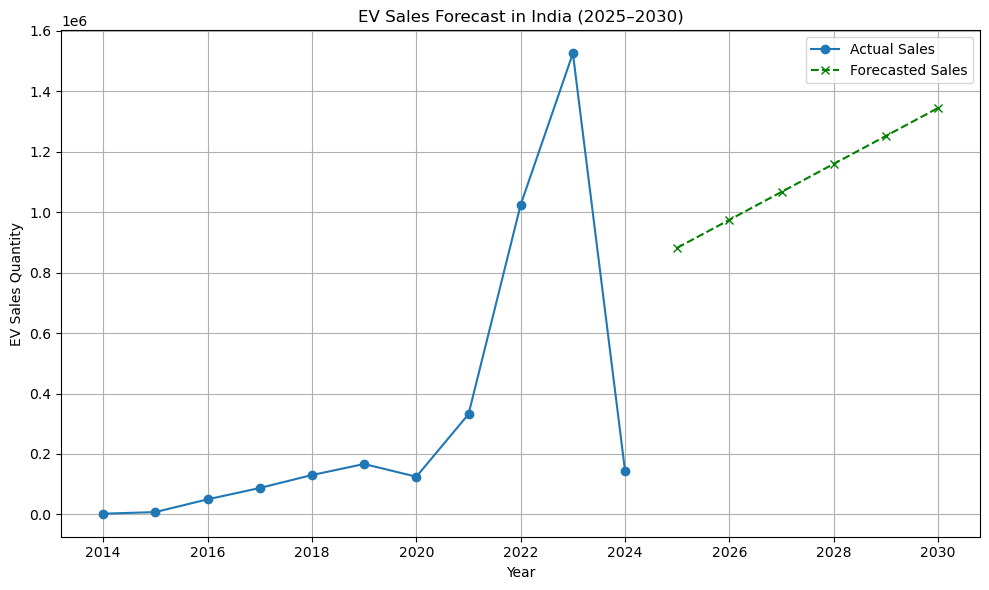

In [15]:
# Plot actual vs forecasted sales
plt.figure(figsize=(10, 6))
plt.plot(yearly_sales['Year'], y_year, marker='o', label='Actual Sales')
plt.plot(future_years, future_preds, marker='x', linestyle='--', color='green', label='Forecasted Sales')
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.title("EV Sales Forecast in India (2025–2030)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Print forecasted values
print("🔮 Forecasted EV Sales (2025–2030):")
for year, pred in zip(future_years.ravel(), future_preds):
    print(f"{year}: {int(pred):,} units")


🔮 Forecasted EV Sales (2025–2030):
2025: 882,017 units
2026: 974,568 units
2027: 1,067,119 units
2028: 1,159,671 units
2029: 1,252,222 units
2030: 1,344,773 units


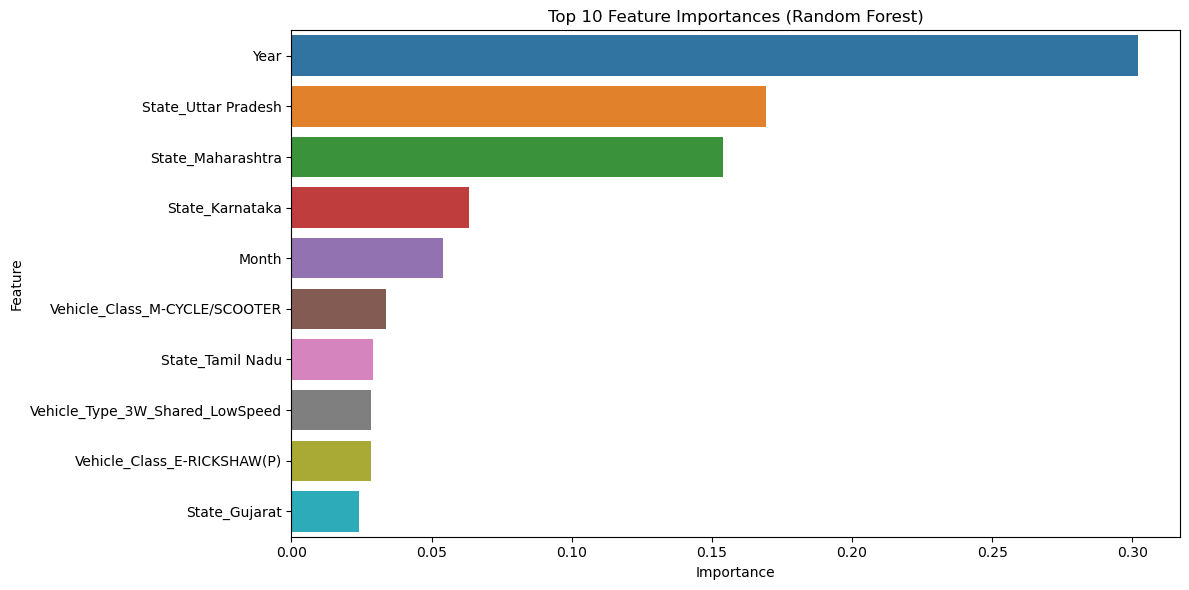

In [17]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


In [19]:
forecast_df = pd.DataFrame({
    'Year': future_years.ravel(),
    'Predicted_EV_Sales': future_preds.astype(int)
})

forecast_df.to_csv("EV_Sales_Forecast_2025_2030.csv", index=False)
print(f"✅ CSV saved successfully at: {forecast_df}")

✅ CSV saved successfully at:    Year  Predicted_EV_Sales
0  2025              882017
1  2026              974568
2  2027             1067119
3  2028             1159671
4  2029             1252222
5  2030             1344773
